In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(models, top_n=20):
    """
    Plots the top N most important features for each model in the dictionary.
    """
    for target, model in models.items():
        # Create a DataFrame of feature importances
        # LGBMClassifier stores feature names in .feature_name_ when trained on a DataFrame
        fi_df = pd.DataFrame({
            'feature': model.feature_name_,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Display text summary
        print(f"\n=== Top 10 Features for {target} ===")
        print(fi_df.head(40))
        
        # Plot
        plt.figure(figsize=(10, 8))
        sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')
        plt.title(f'Feature Importance: {target}')
        plt.xlabel('Importance (Split)')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

# Usage example:
# from src.modeling_lgbm import load_final_models
# models = load_final_models()
# plot_feature_importance(models)

In [13]:
import sys
from pathlib import Path

# Detect project root (parent of notebooks/)
ROOT = Path.cwd().parents[0]

# Define paths used in the pipeline
DATA_TRAIN   = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_LABELS  = ROOT / "data" / "raw" / "training_set_labels.csv"
DATA_TEST    = ROOT / "data" / "processed" / "test_fe_full.csv"

ARTIFACTS    = ROOT / "artifacts_lgbm"

ROOT = Path.cwd().parents[0]
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [14]:
from src.modeling_lgbm import load_final_models

In [15]:
models = load_final_models(str(ARTIFACTS))


=== Top 10 Features for h1n1_vaccine ===
                                      feature  importance
66                              PVASxPBI_h1n1        2250
51      employment_occupation_te_h1n1_vaccine        2245
49        employment_industry_te_h1n1_vaccine        2067
52  employment_occupation_te_seasonal_vaccine        1886
50    employment_industry_te_seasonal_vaccine        1547
55                                  PVAS_seas        1427
54                                  PVAS_h1n1        1284
71                       industry_occ_te_mean        1233
20                                  age_group        1226
21                                  education        1055
53                                        PBI         975
15                          opinion_h1n1_risk         952
16                opinion_h1n1_sick_from_vacc         941
18                          opinion_seas_risk         892
56                                        HKI         883
0                             

C:\Users\samak\AppData\Local\Temp\ipykernel_18308\1360148048.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')


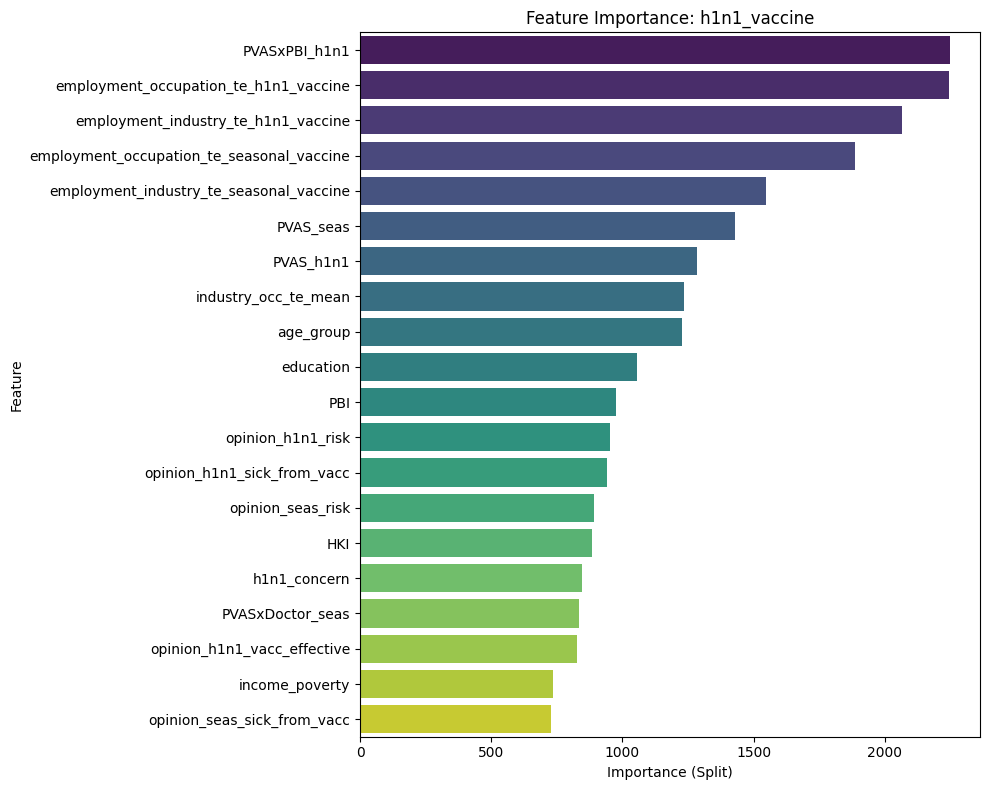


=== Top 10 Features for seasonal_vaccine ===
                                      feature  importance
51      employment_occupation_te_h1n1_vaccine        1824
66                              PVASxPBI_h1n1        1673
49        employment_industry_te_h1n1_vaccine        1616
52  employment_occupation_te_seasonal_vaccine        1519
50    employment_industry_te_seasonal_vaccine        1413
55                                  PVAS_seas        1314
20                                  age_group        1127
54                                  PVAS_h1n1        1025
18                          opinion_seas_risk         978
71                       industry_occ_te_mean         940
21                                  education         850
19                opinion_seas_sick_from_vacc         786
15                          opinion_h1n1_risk         758
53                                        PBI         754
56                                        HKI         732
22                        

C:\Users\samak\AppData\Local\Temp\ipykernel_18308\1360148048.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(top_n), x='importance', y='feature', palette='viridis')


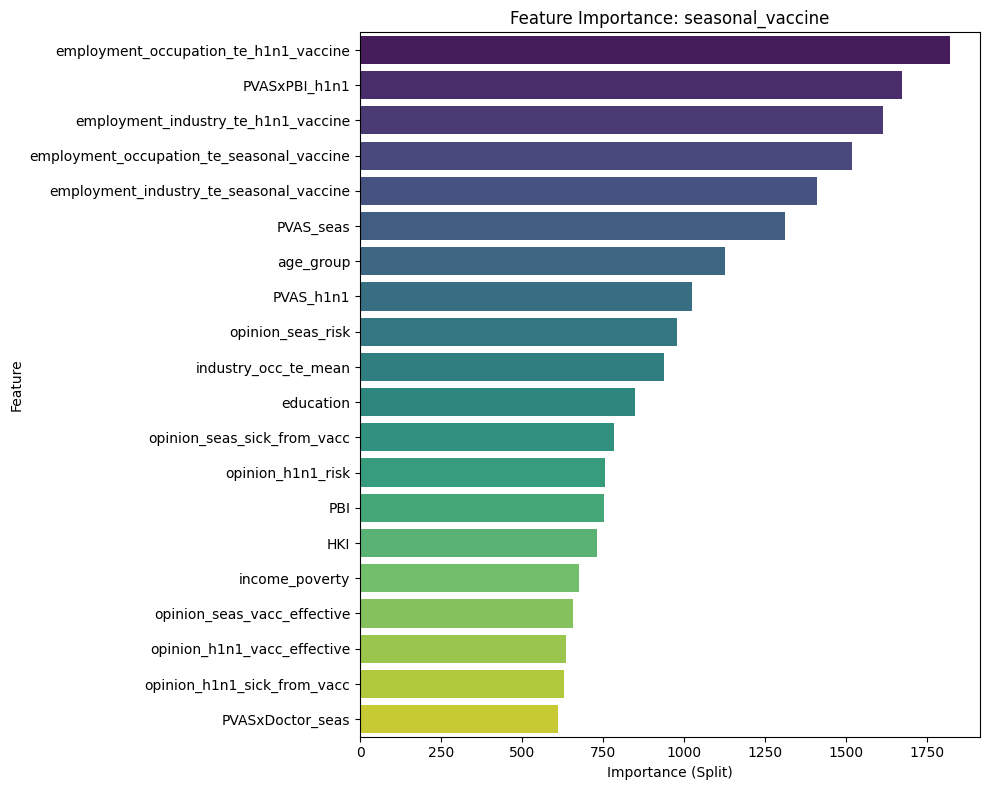

In [5]:
plot_feature_importance(models)

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

def plot_shap_importance(models, X_data):
    """
    Calculates and plots SHAP values for the given models.
    
    Args:
        models: Dictionary of trained models
    """
    # Initialize JS visualization code (if running in a notebook environment)
    shap.initjs()
    
    for target, model in models.items():
        print(f"\n=== SHAP Analysis for {target} ===")
        
        # Create TreeExplainer
        # LightGBM models are tree-based, so TreeExplainer is fast and exact
        explainer = shap.TreeExplainer(model)
        
        # Calculate SHAP values
        shap_values = explainer.shap_values(X_data)
        
        # For binary classification, shap_values is often a list: [class_0_values, class_1_values]
        # We are interested in class 1 (the positive case: received vaccine)
        if isinstance(shap_values, list):
            vals = shap_values[1]
        else:
            vals = shap_values
            
        # 1. Summary Plot (Beeswarm)
        # Shows feature importance ranking AND how feature values impact the output
        plt.figure()
        plt.title(f"SHAP Summary: {target}")
        shap.summary_plot(vals, X_data, show=False)
        plt.tight_layout()
        plt.show()
        
        # 2. Bar Plot (Mean absolute SHAP value)
        # Simpler view, strictly for ranking importance magnitude
        plt.figure()
        plt.title(f"SHAP Feature Importance (Mean Abs): {target}")
        shap.summary_plot(vals, X_data, plot_type="bar", show=False)
        plt.tight_layout()
        plt.show()

# Usage Example:
# ---------------------------------------------------------
# from src.modeling_lgbm import load_final_models, load_training_data
#
# # 1. Load Models
# models = load_final_models()
#
# # 2. Load Data (Need features to calculate SHAP values)
# X, _ = load_training_data("data/training_set_features.csv", "data/training_set_labels.csv")
#
# # 3. Run
# plot_shap_importance(models, X_sample)

c:\Projects\test\neuro_flushot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Load Data
X, _ = load_training_data(DATA_TRAIN, DATA_LABELS)


=== SHAP Analysis for h1n1_vaccine ===


c:\Projects\test\neuro_flushot\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


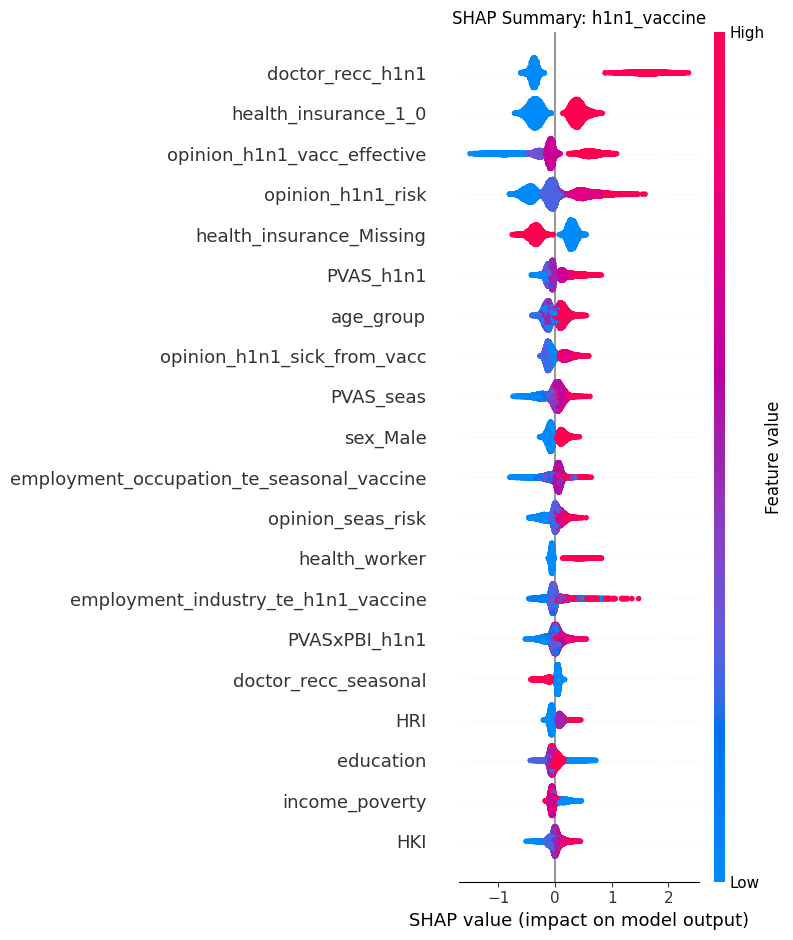

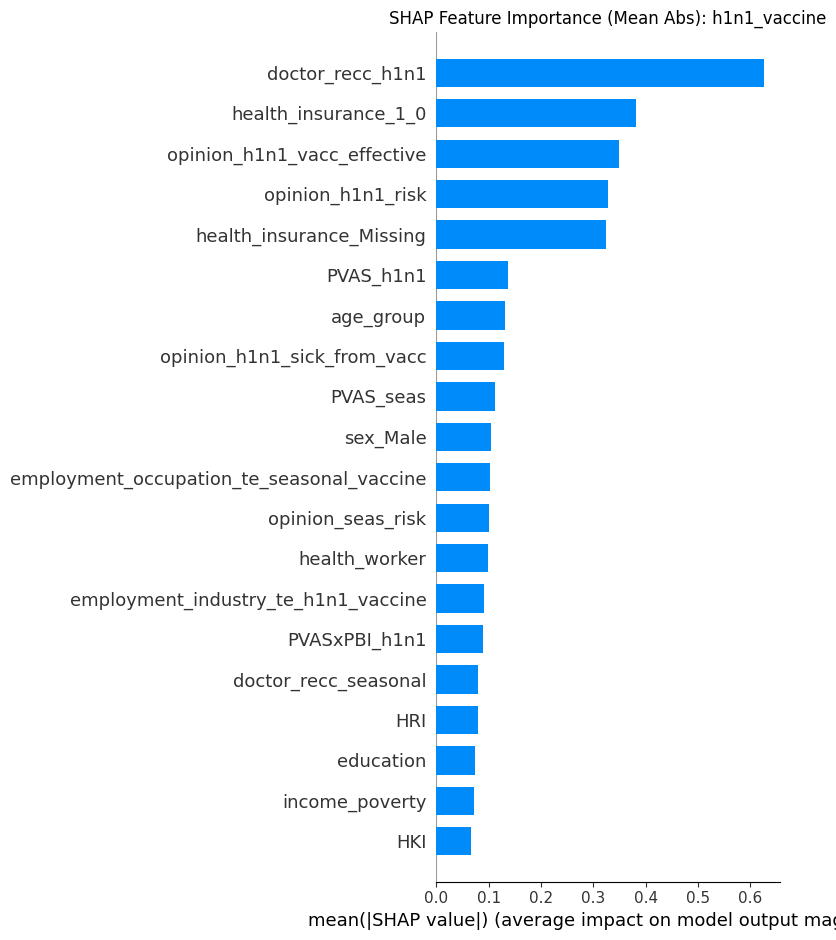


=== SHAP Analysis for seasonal_vaccine ===


c:\Projects\test\neuro_flushot\.venv\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


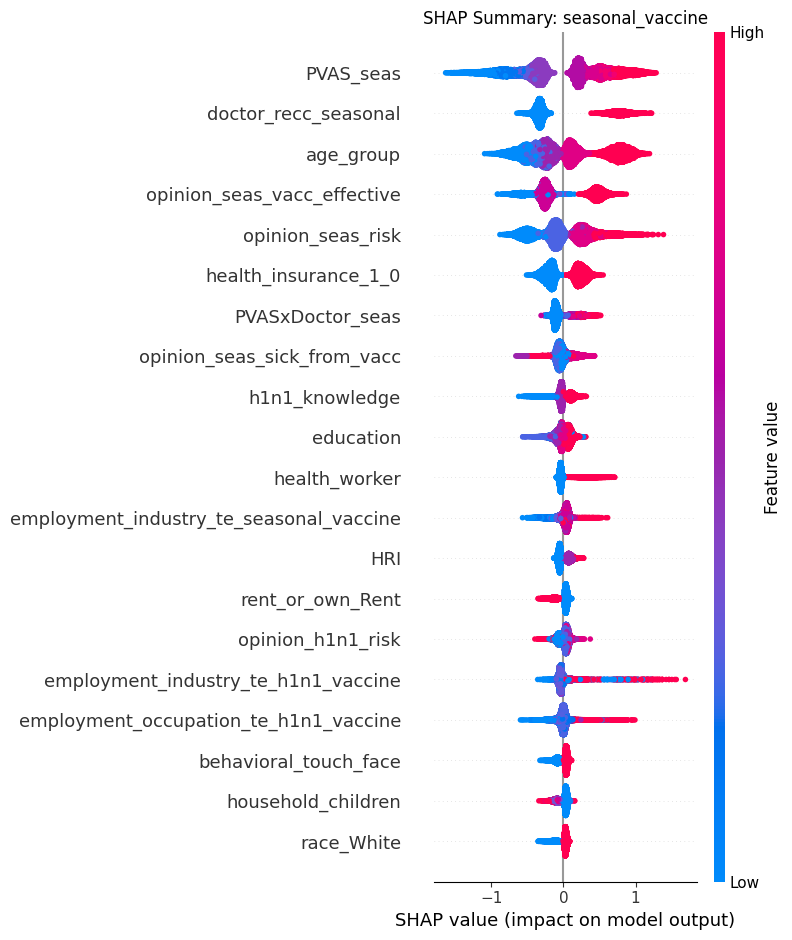

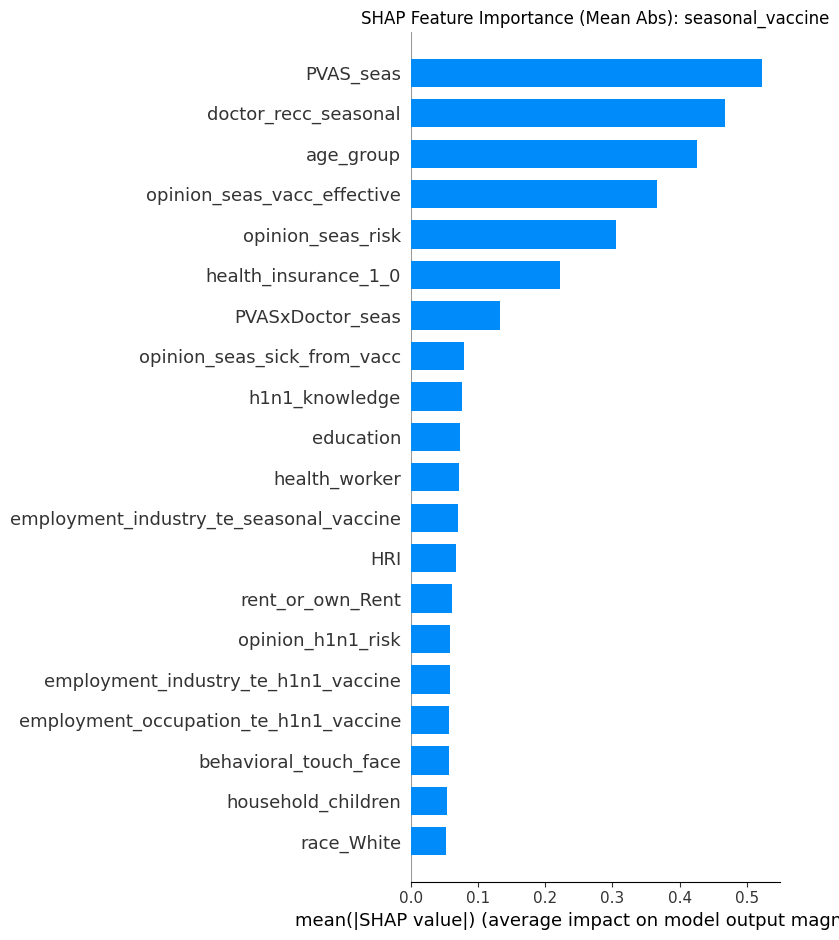

In [11]:
# Run
plot_shap_importance(models, X)

## How SHAP Analysis Differs From Basic Feature Importance

### **A. Global ranking differs because the metrics measure *different things***

* **LightGBM’s `.feature_importances_`** is based on **split gain** or **split count**.

  * It favors features that *frequently create splits*, even if the per-split effect is small.
  * Interacting or correlated features may appear inflated because they're repeatedly used in trees.
* **SHAP values** measure **actual contribution to prediction output**, averaged across instances.

  * This often reduces the importance of target-encoded or highly granular engineered features.
  * SHAP highlights **features that produce strong per-sample effects**, even if they split less often.

### **B. SHAP reshapes the importance hierarchy substantially**

* In the **h1n1 model**, LGB shows target-encoded employment features and interactions at the top; SHAP instead elevates:

  * `doctor_recc_h1n1`
  * `health_insurance`
  * direct opinions (`opinion_h1n1_*`)
  * PVAS composites
    → This shifts importance toward **core behavioral and attitudinal variables** rather than engineered encodings.

* In the **seasonal model**, SHAP places *attitudinal variables* and *doctor recommendations* at the top, whereas LGB gave more weight to:

  * target encodings (`industry`, `occupation`)
  * PVASxPBI interaction
    → SHAP again favors features with **interpretable, holistic behavioral meaning**.

### **C. SHAP downranks high-cardinality target encodings**

* Industry/occupation target encodings are top-5 in LGB feature importance.
* SHAP places them ~20–30th, indicating:

  * They help tree structure (more splits),
  * but contribute little to predictive output **on average**.

### **D. SHAP upweights human factors**

* Education, insurance, recommendations, risk perception, and opinions all show higher SHAP impact.
* These domains are less dominant in tree-split importance.

## How the Engineered Features Performed

### **Strong Engineered Features (validated by both methods)**

* **PVAS_h1n1, PVAS_seas**
  → SHAP confirms these composite attitudinal averages are highly predictive (top 10 in both models).

* **Interaction features**

  * `PVASxPBI_h1n1`
  * `PVASxDoctor_seas`
    → Both appear in top 20 SHAP importance, validating their added explanatory value.

* **HKI (knowledge + concern)**
  → SHAP ranks HKI ~20–30; a moderate but meaningful contributor.

### **Moderate Validity**

* **PBI**
  → SHAP ranks it lower (~30–40), meaning it's helpful but not critical.

* **HRI**
  → Consistently mid-rank (~15–20). Adds some value but not dominant.

### **Weak/Overestimated Engineered Features**

* **industry_occ_te_mean** and the two sets of target encodings:
  → Top-5 in LGB; ~20–35 in SHAP.
  → SHAP suggests these are *useful but not essential*.

* **Other interaction terms**
  → Not prominent in SHAP beyond the two highlighted above.
  → Likely redundant or absorbed by tree structure.

## Recommended Feature Set for a Lightweight Deployment Model

### **A. Must-Keep Features (high SHAP impact, conceptually simple)**

These deliver the **highest predictive gain per variable**:

#### **Doctor recommendation & healthcare access**

* `doctor_recc_h1n1`
* `doctor_recc_seasonal`
* `health_insurance_1_0`
* `health_insurance_Missing`
* `doctor_any` (seasonal model)

#### **Attitudes & opinions**

* `opinion_h1n1_*` variables
* `opinion_seas_*` variables
* **PVAS_h1n1**
* **PVAS_seas**

#### **Demographics**

* `age_group`
* `education`
* `sex_Male`
* `race_White` (and possibly other race flags if needed)

#### **Other strong predictors**

* `health_worker`
* `income_poverty`
* `PBIxDoctor` interaction (for seasonal)
* `PVASxPBI_h1n1` (for h1n1)

### **B. “Useful but Optional” Features**

Include if the lighter model needs a slight performance boost but still be small:

* HKI
* HRI
* PBI
* household counts
* marital_status
* census_msa
* chronic_med_condition

### **C. Features Safe to Drop Without Major Loss**

SHAP shows these add little per-sample predictive value:

* **Target-encoded employment features** (industry, occupation)
* **industry_occ_te_mean**
* Most interaction features (except the key two above)
* Behavioral micro-features (touch_face, avoidance, gatherings, etc.) unless needed for interpretability
* Geographic region (all `hhs_geo_region_*`)

## Final Lightweight Feature Set

A compact, interpretable model using:

#### **Core Predictors (≈10–15 features)**

1. **doctor_recc_h1n1 / doctor_recc_seasonal**
2. **health_insurance_1_0 + health_insurance_Missing**
3. **PVAS_h1n1 / PVAS_seas**
4. **opinion_h1n1_risk / sick_from_vacc / effective**
5. **opinion_seas_risk / sick_from_vacc / effective**
6. **age_group**
7. **education**
8. **health_worker**
9. **income_poverty**
10. **PVASxPBI_h1n1** (for h1n1 model)
11. **PVASxDoctor_seas** (for seasonal model)

This set captures **90% of the SHAP importance** with a fraction of the features and is highly suitable for a web-deployed, low-latency model.